In [1]:
import numpy as np
import matplotlib.pyplot as plt

def make_W(kind, N, J=1., p=None, D=None, rng=None, dtype=np.float32):
    rng = np.random.default_rng(rng)
    if kind == "gaussian":    return rng.normal(0, J/np.sqrt(N), (N, N)).astype(dtype)   # var = J^2/N
    if kind == "full":        return np.full((N, N), J/N, dtype=dtype)
    if kind == "erdos_renyi":
        if p is None: raise ValueError("need p")
        k = max(p*N, 1)
        return ((rng.random((N, N)) < p) * (J/k)).astype(dtype)
    if kind == "data":
        if D is None: raise ValueError("need D")
        return (J * np.asarray(D, dtype=dtype))
    raise ValueError("kind must be 'gaussian', 'full', 'erdos_renyi', or 'data'")

def init_r(N, kind="uniform", scale=1., rng=None, dtype=np.float32):
    rng = np.random.default_rng(rng)
    if kind == "uniform":
        return rng.uniform(-scale, scale, N).astype(dtype)
    if kind == "gaussian":
        return rng.normal(0, scale, N).astype(dtype)
    if kind == "zeros":
        return np.zeros(N, dtype=dtype)
    if kind == "ones":
        return np.ones(N, dtype=dtype)
    raise ValueError("kind must be 'uniform', 'gaussian', 'zeros', or 'ones'")

def run_reservoir(W, t, N=None, eps=1e-2, M=100, rng=None,
                  init="uniform", init_scale=1., dtype=np.float32):
    W = np.asarray(W, dtype=dtype)
    N = W.shape[0] if N is None else N
    steps = max(1, round(t/eps))
    
    if not (1 <= M <= steps): 
        raise ValueError("need 1 <= M <= round(t/eps)")
    
    r = init_r(N, kind=init, scale=init_scale, rng=rng, dtype=dtype)
    take = np.linspace(0, steps - 1, M, dtype=int)
    out, j = np.empty((M, N), dtype=dtype), 0
    
    for i in range(steps):
        r += eps * (-r + np.tanh(W @ r))
        if i == take[j]:
            out[j] = r
            j += 1
            if j == M: break
    return out

W = make_W("gaussian", N=1500, J=1.2, rng=0)
samples = run_reservoir(W, t=100.0, eps=1e-2, M=200, rng=1,
                        init="uniform", init_scale=1.0)

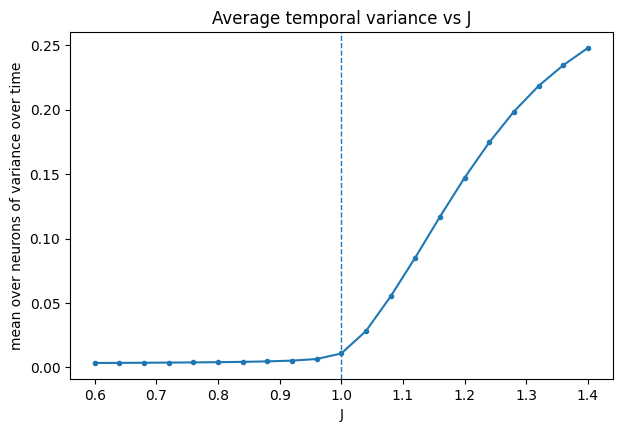

In [2]:
def mean_time_variance(samples):
    X = np.asarray(samples)
    return X.var(axis=0).mean()

def plot_mean_time_variance_vs_J(
    J_values,
    N=700,
    t=80.0,
    eps=1e-2,
    M=160,
    net_seed=0,
    init_seed=1,
    kind="gaussian",
    ax=None,
):
    vals = []
    for J in J_values:
        W = make_W(kind, N=N, J=J, rng=net_seed)
        samples = run_reservoir(
            W, t=t, eps=eps, M=M, rng=init_seed,
            init="uniform", init_scale=1.0
        )
        vals.append(mean_time_variance(samples))

    vals = np.asarray(vals)

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(J_values, vals, marker="o", ms=3)
    ax.axvline(1.0, linestyle="--", linewidth=1)
    ax.set(
        xlabel="J",
        ylabel="mean over neurons of variance over time",
        title="Average temporal variance vs J"
    )
    return vals, ax

J_values = np.linspace(0.6, 1.4, 21)
vals, ax = plot_mean_time_variance_vs_J(J_values)
plt.show()


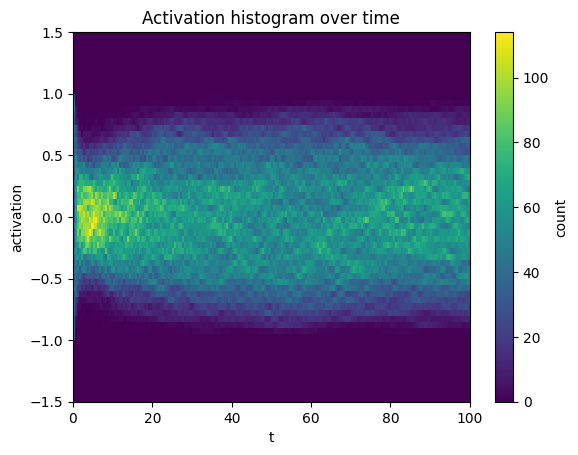

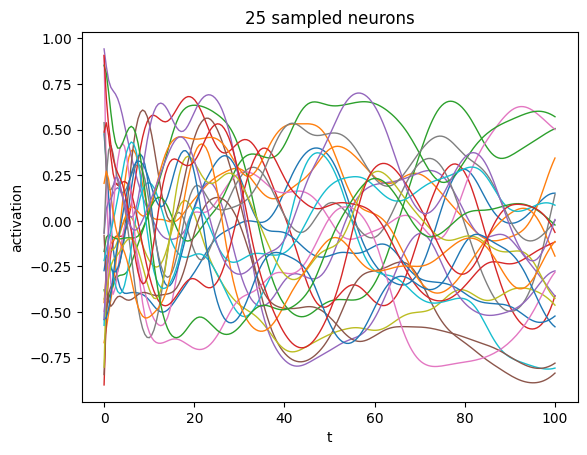

In [3]:
def plot_sand(samples, t, n=50, vmin=-1, vmax=1, ax=None):
    X = np.asarray(samples)
    M = X.shape[0]
    edges = np.linspace(vmin, vmax, n + 1)
    H = np.empty((M, n), int)
    for i, s in enumerate(np.sort(X, axis=1)):               # sort each time slice
        H[i] = np.diff(np.searchsorted(s, edges))            # fast histogram from sorted values
    if ax is None: _, ax = plt.subplots()
    im = ax.imshow(H.T, origin="lower", aspect="auto",
                   extent=[0, t, vmin, vmax], interpolation="nearest")
    ax.set(xlabel="t", ylabel="activation", title="Activation histogram over time")
    plt.colorbar(im, ax=ax, label="count")
    return H, ax

def plot_neurons(samples, t, n=20, rng=None, ax=None):
    X = np.asarray(samples)
    M, N = X.shape
    idx = np.random.default_rng(rng).choice(N, min(n, N), replace=False)
    tt = np.linspace(0, t, M)
    if ax is None: _, ax = plt.subplots()
    ax.plot(tt, X[:, idx], lw=1)
    ax.set(xlabel="t", ylabel="activation", title=f"{len(idx)} sampled neurons")
    return idx, ax

plot_sand(samples, t=100.0, n=60, vmin=-1.5, vmax=1.5)
plt.show()

plot_neurons(samples, t=100.0, n=25, rng=0)
plt.show()

<Axes: title={'center': 'eig(W), rho=2.03'}, xlabel='Re', ylabel='Im'>

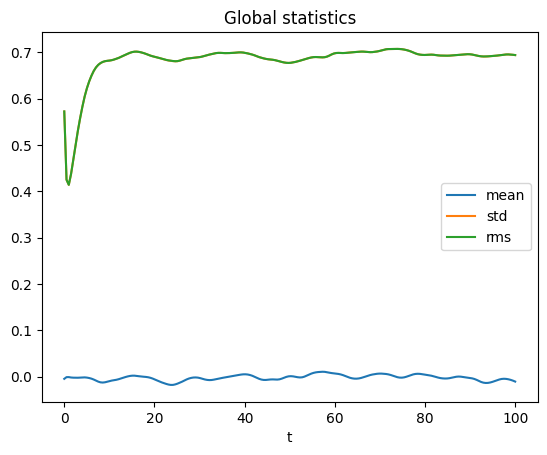

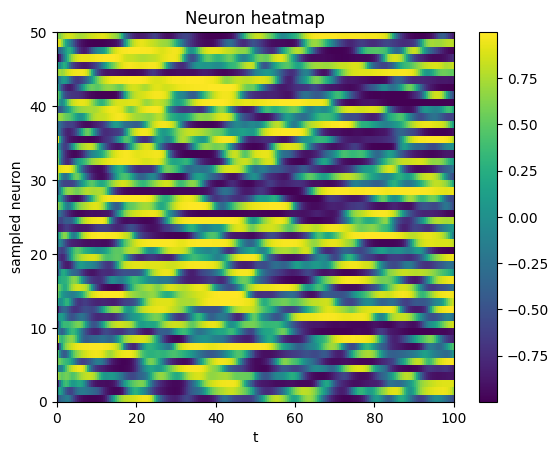

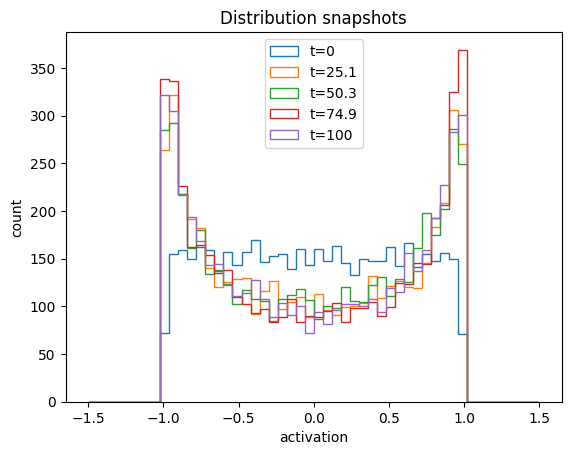

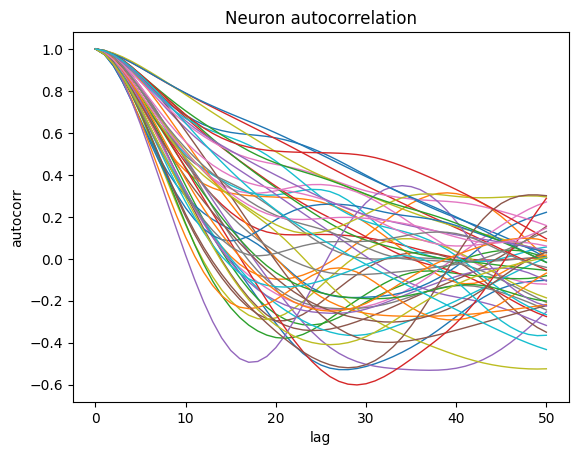

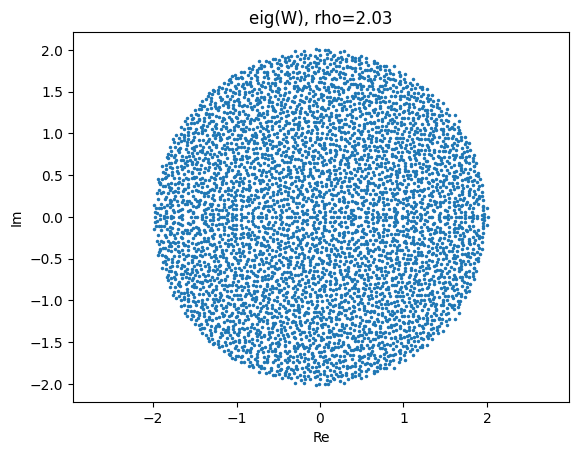

In [7]:
def plot_stats(samples, t, ax=None):
    X = np.asarray(samples)
    tt = np.linspace(0, t, len(X))
    m, s = X.mean(1), X.std(1)
    q = np.sqrt((X*X).mean(1))
    if ax is None: _, ax = plt.subplots()
    ax.plot(tt, m, label="mean")
    ax.plot(tt, s, label="std")
    ax.plot(tt, q, label="rms")
    ax.set(xlabel="t", title="Global statistics")
    ax.legend()
    return ax

def plot_neuron_heatmap(samples, t, n=50, rng=None, ax=None):
    X = np.asarray(samples)
    M, N = X.shape
    idx = np.random.default_rng(rng).choice(N, min(n, N), replace=False)
    if ax is None: _, ax = plt.subplots()
    im = ax.imshow(X[:, idx].T, origin="lower", aspect="auto",
                   extent=[0, t, 0, len(idx)], interpolation="nearest")
    ax.set(xlabel="t", ylabel="sampled neuron", title="Neuron heatmap")
    plt.colorbar(im, ax=ax)
    return idx, ax

def plot_snapshots(samples, t, times=(0.0, 0.5, 1.0), bins=50, vmin=-1, vmax=1):
    X = np.asarray(samples)
    M = len(X)
    tt = np.linspace(0, t, M)
    _, ax = plt.subplots()
    for u in times:
        i = min(int(u*(M-1)), M-1) if 0 <= u <= 1 else np.argmin(abs(tt-u))
        ax.hist(X[i], bins=np.linspace(vmin, vmax, bins+1), histtype="step",
                label=f"t={tt[i]:.3g}")
    ax.set(xlabel="activation", ylabel="count", title="Distribution snapshots")
    ax.legend()
    return ax

def plot_autocorr(samples, n=1, max_lag=None, rng=None, ax=None):
    X = np.asarray(samples)
    M, N = X.shape
    idx = np.random.default_rng(rng).choice(N, min(n, N), replace=False)
    if max_lag is None: max_lag = M // 4
    if ax is None: _, ax = plt.subplots()
    for j in idx:
        x = X[:, j] - X[:, j].mean()
        c = np.correlate(x, x, mode="full")[M-1:M+max_lag] / (x @ x + 1e-12)
        ax.plot(c, lw=1)
    ax.set(xlabel="lag", ylabel="autocorr", title="Neuron autocorrelation")
    return idx, ax

def plot_eigs(W, ax=None):
    z = np.linalg.eigvals(W)
    if ax is None: _, ax = plt.subplots()
    ax.plot(z.real, z.imag, ".", ms=3)
    ax.set(xlabel="Re", ylabel="Im", title=f"eig(W), rho={np.abs(z).max():.3g}")
    ax.axis("equal")
    return ax

plot_stats(samples, t=100.0)
plot_neuron_heatmap(samples, t=100.0, n=50, rng=0)
plot_snapshots(samples, t=100.0, times=(0, 25, 50, 75, 100), bins=50, vmin=-1.5, vmax=1.5)
plot_autocorr(samples, n=50, rng=0)
plot_eigs(W)


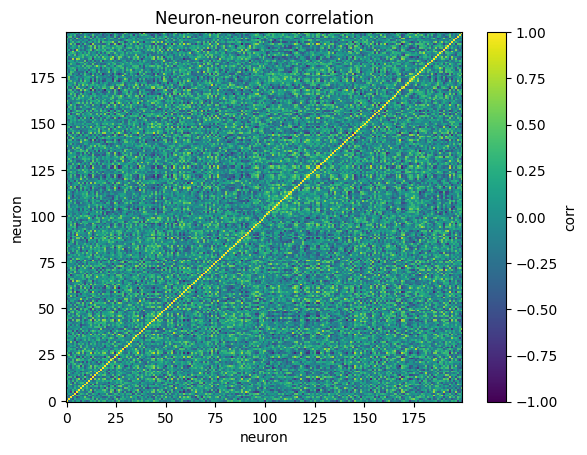

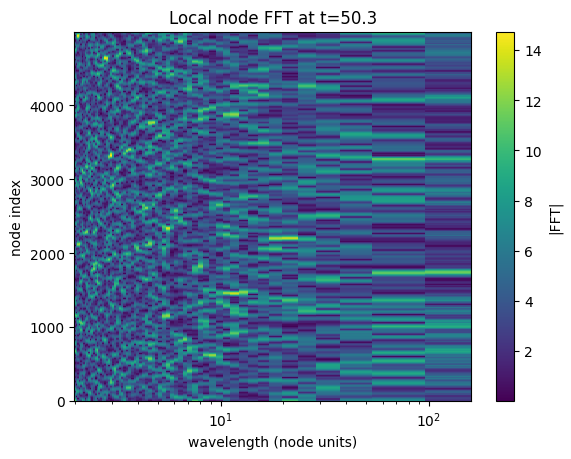

In [8]:
def _centers_to_edges(x):
    x = np.asarray(x, dtype=float)
    if x.ndim != 1:
        raise ValueError("x must be 1D")
    if len(x) == 1:
        dx = 0.5 * (abs(x[0]) if x[0] != 0 else 1.0)
        return np.array([x[0] - dx, x[0] + dx])
    mid = 0.5 * (x[:-1] + x[1:])
    left = x[0] - (mid[0] - x[0])
    right = x[-1] + (x[-1] - mid[-1])
    return np.r_[left, mid, right]


def plot_neuron_correlation_matrix(samples, n=None, rng=None, ax=None, absolute=False):
    """
    Correlation between neuron time series.
    samples: shape (M, N), rows = times, cols = neurons

    n: if given, randomly plot only n neurons
    """
    X = np.asarray(samples, dtype=float)
    M, N = X.shape

    if n is None or n >= N:
        idx = np.arange(N)
        Y = X
    else:
        idx = np.random.default_rng(rng).choice(N, n, replace=False)
        Y = X[:, idx]

    # columns = neuron trajectories over time
    C = np.corrcoef(Y, rowvar=False)
    if absolute:
        C = np.abs(C)

    if ax is None:
        _, ax = plt.subplots()

    im = ax.imshow(
        C,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        vmin=0 if absolute else -1,
        vmax=1,
    )
    ax.set(
        xlabel="neuron",
        ylabel="neuron",
        title="Neuron-neuron correlation"
    )
    plt.colorbar(im, ax=ax, label="|corr|" if absolute else "corr")
    return idx, C, ax

def plot_node_wavelength_fft(samples, t, time=None, frac=1.0, window=128, dx=1.0,
                             coeff="abs", log_x=True, ax=None):
    """
    Local FFT along the node axis for one snapshot.

    This keeps node index on the y-axis by using a sliding window FFT.
    A plain FFT over all nodes would not retain node position.

    coeff: "abs", "power", "real", or "imag"
    dx: spacing between adjacent nodes
    """
    X = np.asarray(samples, dtype=float)
    M, N = X.shape
    tt = np.linspace(0, t, M)

    if time is None:
        i = int(np.clip(round(frac * (M - 1)), 0, M - 1))
    else:
        i = int(np.argmin(np.abs(tt - time)))

    x = X[i]
    w = int(window)
    if not (2 <= w <= N):
        raise ValueError("need 2 <= window <= number of nodes")

    pad_left = w // 2
    pad_right = w - 1 - pad_left
    xpad = np.pad(x, (pad_left, pad_right), mode="reflect")

    windows = np.lib.stride_tricks.sliding_window_view(xpad, w)[:N]
    windows = windows - windows.mean(axis=1, keepdims=True)
    taper = np.hanning(w)

    F = np.fft.rfft(windows * taper, axis=1)[:, 1:]   # drop DC
    freqs = np.fft.rfftfreq(w, d=dx)[1:]
    wavelengths = 1.0 / freqs

    order = np.argsort(wavelengths)   # increasing wavelength left->right
    wavelengths = wavelengths[order]
    F = F[:, order]

    if coeff == "abs":
        A = np.abs(F)
        cbar = "|FFT|"
    elif coeff == "power":
        A = np.abs(F) ** 2
        cbar = "power"
    elif coeff == "real":
        A = F.real
        cbar = "Re(FFT)"
    elif coeff == "imag":
        A = F.imag
        cbar = "Im(FFT)"
    else:
        raise ValueError("coeff must be 'abs', 'power', 'real', or 'imag'")

    if ax is None:
        _, ax = plt.subplots()

    xe = _centers_to_edges(wavelengths)
    ye = np.arange(N + 1) - 0.5

    im = ax.pcolormesh(xe, ye, A, shading="auto")
    if log_x:
        ax.set_xscale("log")

    ax.set(
        xlabel="wavelength (node units)",
        ylabel="node index",
        title=f"Local node FFT at t={tt[i]:.3g}",
    )
    plt.colorbar(im, ax=ax, label=cbar)
    return wavelengths, A, ax


plot_neuron_correlation_matrix(samples, n=200, rng=0)

plot_node_wavelength_fft(
    samples, t=100.0,
    time=50.0,       # or frac=0.5
    window=128,
    coeff="abs",
    log_x=True
)

plt.show()